<a href="https://colab.research.google.com/github/simrankhan-coder/H-M-Fashion-Recommendation-System---Full-Pipeline/blob/main/hm_full_pipeline_memory_optimized.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# H&M Fashion Recommendation System — Memory-Optimized Full Pipeline

This notebook combines EDA, RFM customer segmentation, and the recommendation
model (candidate generation + ALS + LightGBM Ranker) into **one memory-safe
pipeline**



## Setup

In [4]:
import gc
import numpy as np
import pandas as pd

def mem_check(label=""):
    import psutil
    used = psutil.Process().memory_info().rss / 1024**3
    print(f"[{label}] Process memory: {used:.2f} GB")

# !pip install psutil --quiet   # uncomment if not already installed
mem_check("start")


[start] Process memory: 0.49 GB


## Phase A.1 — Memory-Efficient Data Loading


In [5]:
from datasets import load_dataset

# Login using e.g. `huggingface-cli login` to access this dataset if needed
articles_hf     = load_dataset("einrafh/hnm-fashion-recommendations-data", "articles")
customers_hf    = load_dataset("einrafh/hnm-fashion-recommendations-data", "customers")
transactions_hf = load_dataset("einrafh/hnm-fashion-recommendations-data", "transactions")

articles = articles_hf["train"].to_pandas()
del articles_hf
gc.collect()

customers = customers_hf["train"].to_pandas()
del customers_hf
gc.collect()

transactions = transactions_hf["train"].to_pandas()
del transactions_hf
gc.collect()

mem_check("after loading (pre dtype optimization)")
print("Articles:", articles.shape, "| Customers:", customers.shape, "| Transactions:", transactions.shape)


README.md:   0%|          | 0.00/7.75k [00:00<?, ?B/s]

data/raw/articles.csv:   0%|          | 0.00/36.1M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

data/raw/customers.csv:   0%|          | 0.00/207M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

data/raw/transactions_train.csv:   0%|          | 0.00/3.49G [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

[after loading (pre dtype optimization)] Process memory: 3.20 GB
Articles: (105542, 25) | Customers: (1371980, 7) | Transactions: (31788324, 5)


## Phase A.2 — Dtype Optimization (do this immediately, not after EDA)


In [6]:
# --- Transactions ---
transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])
transactions["customer_id"] = transactions["customer_id"].astype("category")
transactions["article_id"] = transactions["article_id"].astype("category")
transactions["sales_channel_id"] = transactions["sales_channel_id"].astype("int8")
transactions["price"] = transactions["price"].astype("float32")

# --- Articles ---
article_category_cols = [
    "product_type_name", "product_group_name", "graphical_appearance_name",
    "colour_group_name", "perceived_colour_value_name", "perceived_colour_master_name",
    "department_name", "index_code", "index_name", "index_group_name",
    "section_name", "garment_group_name"
]
for col in article_category_cols:
    if col in articles.columns:
        articles[col] = articles[col].astype("category")
articles["article_id"] = articles["article_id"].astype("category")

# --- Customers ---
for col in ["club_member_status", "fashion_news_frequency"]:
    if col in customers.columns:
        customers[col] = customers[col].astype("category")
customers["customer_id"] = customers["customer_id"].astype("category")

gc.collect()
mem_check("after dtype optimization")

for name, df in [("Articles", articles), ("Customers", customers), ("Transactions", transactions)]:
    print(f"{name}: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


[after dtype optimization] Process memory: 2.75 GB
Articles: 41.3 MB
Customers: 367.2 MB
Transactions: 820.5 MB


## Phase A.3 — Condensed Data Quality Overview

(Duplicate check reuses the already-loaded `transactions` dataframe instead
of calling `.to_pandas()` again.)

In [7]:
for name, df in [("Articles", articles), ("Customers", customers), ("Transactions", transactions)]:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Shape           : {df.shape}")
    print(f"Missing values  : {df.isnull().sum().sum():,}")
    print(f"Duplicate rows  : {df.duplicated().sum():,}")
    print()

# Duplicate transactions are kept — they represent valid repeat purchases
# (e.g. buying 2 identical t-shirts), which is a useful signal for
# collaborative filtering / popularity models, not a data error.


Articles
Shape           : (105542, 25)
Missing values  : 416
Duplicate rows  : 0

Customers
Shape           : (1371980, 7)
Missing values  : 1,840,560
Duplicate rows  : 0

Transactions
Shape           : (31788324, 5)
Missing values  : 0
Duplicate rows  : 2,974,905



## Phase A.4 — Key EDA (condensed to the plots that matter for modeling)

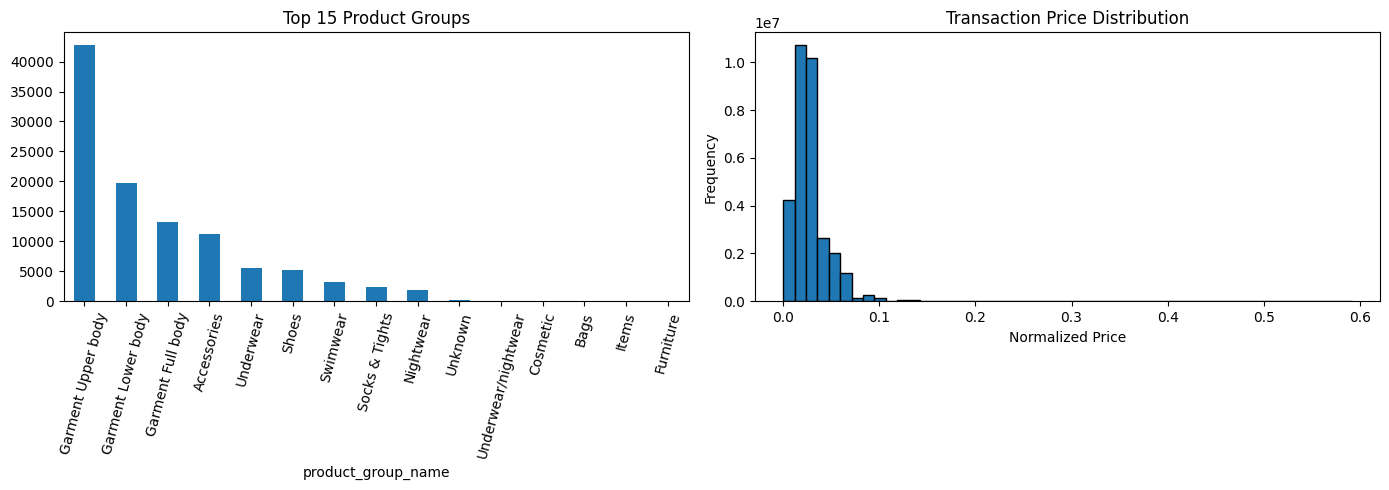

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

articles["product_group_name"].value_counts().head(15).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 15 Product Groups")
axes[0].tick_params(axis="x", rotation=75)

transactions["price"].plot(kind="hist", bins=50, ax=axes[1], edgecolor="black")
axes[1].set_title("Transaction Price Distribution")
axes[1].set_xlabel("Normalized Price")

plt.tight_layout()
plt.show()


## Phase A.5 — RFM Customer Segmentation



In [9]:
snapshot_date = transactions["t_dat"].max() + pd.Timedelta(days=1)

rfm = (
    transactions.groupby("customer_id", observed=True)
    .agg(
        Recency=("t_dat", lambda x: (snapshot_date - x.max()).days),
        Frequency=("article_id", "count"),
        Monetary=("price", "sum"),
    )
    .reset_index()
)

rfm["R_Score"] = pd.qcut(rfm["Recency"], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)

def customer_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "Champions"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 4:
        return "Loyal Customers"
    elif row["R_Score"] >= 4 and row["F_Score"] >= 2:
        return "Potential Loyalists"
    elif row["R_Score"] >= 4 and row["F_Score"] == 1:
        return "New Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk"
    elif row["R_Score"] <= 2 and row["F_Score"] <= 2:
        return "Lost Customers"
    else:
        return "Needs Attention"

rfm["Customer Segment"] = rfm.apply(customer_segment, axis=1)

mem_check("after RFM")
rfm["Customer Segment"].value_counts()


[after RFM] Process memory: 2.67 GB


,count
Customer Segment,
Champions,344584
Lost Customers,344513
At Risk,200221
Needs Attention,169770
Potential Loyalists,145064
Loyal Customers,119716
New Customers,38413


## Phase A.6 — Free EDA-only Memory Before Modeling

In [10]:
rfm.to_parquet("rfm.parquet")
articles[["article_id", "product_group_name", "colour_group_name", "garment_group_name"]].to_parquet("articles_slim.parquet")

del customers, rfm
gc.collect()
mem_check("after freeing customers/rfm")


[after freeing customers/rfm] Process memory: 2.38 GB


---
# Phase B — Recommendation Modeling (Memory-Optimized)

the model on a **recent rolling window** (last 90
days of transactions) rather than the full 2-year history. This keeps
candidate generation, ALS training, and ranker training all within a
manageable memory footprint, and recent purchases are the most predictive
signal for near-term recommendations anyway.


In [11]:
articles_slim = pd.read_parquet("articles_slim.parquet")

WINDOW_DAYS = 90
max_date = transactions["t_dat"].max()
window_start = max_date - pd.Timedelta(days=WINDOW_DAYS)

recent_transactions = transactions[transactions["t_dat"] >= window_start].copy()

del transactions
gc.collect()
mem_check("after windowing to last 90 days")
print("Recent transactions:", recent_transactions.shape)


[after windowing to last 90 days] Process memory: 2.55 GB
Recent transactions: (3904391, 5)


## Phase B.1 — Time-based Train / Validation Split

In [12]:
val_start = max_date - pd.Timedelta(days=6)

train_df = recent_transactions[recent_transactions["t_dat"] < val_start]
val_df   = recent_transactions[recent_transactions["t_dat"] >= val_start]

print("Train:", train_df.shape, "| Val:", val_df.shape)

val_truth = (
    val_df.groupby("customer_id", observed=True)["article_id"]
    .apply(lambda x: list(set(x)))
    .to_dict()
)
mem_check("after train/val split")


Train: (3664080, 5) | Val: (240311, 5)
[after train/val split] Process memory: 2.59 GB


## Phase B.2 — MAP@12 Evaluation Function

In [13]:
def apk(actual, predicted, k=12):
    if len(predicted) > k:
        predicted = predicted[:k]
    score, hits = 0.0, 0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            hits += 1
            score += hits / (i + 1.0)
    return score / min(len(actual), k) if actual else 0.0

def mapk(truth_dict, pred_dict, k=12):
    scores = [apk(actual, pred_dict.get(cust, []), k) for cust, actual in truth_dict.items()]
    return np.mean(scores)


## Phase B.3 — Popularity Baseline

In [14]:
recent_window = train_df[train_df["t_dat"] >= train_df["t_dat"].max() - pd.Timedelta(days=14)]
top_popular = recent_window["article_id"].value_counts().head(12).index.tolist()

pop_preds = {cust: top_popular for cust in val_truth.keys()}
print("Popularity baseline MAP@12:", mapk(val_truth, pop_preds, k=12))


Popularity baseline MAP@12: 0.006840863590682381


## Phase B.4 — Candidate Generation (merge-free)

Instead of merging the full transactions table with articles (which
duplicates every article column across millions of rows), we use a
**vectorized `.map()` lookup** — a dict-based lookup that adds one column
without duplicating anything.

In [15]:
repurchase = (
    train_df.groupby("customer_id", observed=True)["article_id"]
    .apply(lambda x: list(pd.unique(x))[-12:])
    .to_dict()
)

article_to_group = articles_slim.set_index("article_id")["product_group_name"].to_dict()

# Vectorized lookup - no merge, no row duplication
train_df = train_df.copy()
train_df["product_group_name"] = train_df["article_id"].map(article_to_group)

fav_group = (
    train_df.groupby("customer_id", observed=True)["product_group_name"]
    .agg(lambda x: x.value_counts().idxmax() if len(x) else None)
    .to_dict()
)
group_bestsellers = (
    train_df.groupby("product_group_name", observed=True)["article_id"]
    .apply(lambda x: x.value_counts().head(12).index.tolist())
    .to_dict()
)

mem_check("after candidate source prep")


[after candidate source prep] Process memory: 2.84 GB


## Phase B.5 — ALS Collaborative Filtering (memory-lean settings)

Reduced factor count (32 instead of 64) and float32 throughout — halves the
memory of the user/item factor matrices with only a small accuracy trade-off,
which is a reasonable exchange on a memory-constrained free-tier runtime.

In [17]:
#!pip install implicit --quiet

from scipy.sparse import coo_matrix
from implicit.als import AlternatingLeastSquares

cust_ids = train_df["customer_id"].unique()
article_ids_all = train_df["article_id"].unique()

cust_to_idx = {c: i for i, c in enumerate(cust_ids)}
art_to_idx  = {a: i for i, a in enumerate(article_ids_all)}
idx_to_art  = {i: a for a, i in art_to_idx.items()}

rows_idx = train_df["customer_id"].map(cust_to_idx).values
cols_idx = train_df["article_id"].map(art_to_idx).values
data = np.ones(len(train_df), dtype=np.float32)

user_item = coo_matrix(
    (data, (rows_idx, cols_idx)), shape=(len(cust_ids), len(article_ids_all))
).tocsr()

als_model = AlternatingLeastSquares(
    factors=32, regularization=0.05, iterations=15,
    random_state=42, dtype=np.float32
)
als_model.fit(user_item)

mem_check("after ALS training")
print("ALS trained:", user_item.shape)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 101.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:28: UserWarning: Disabling GPU support because of 'libcublas.so.13: cannot open shared object file: No such file or directory'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/implicit/cpu/als.py:96: RuntimeWarning: OpenBLAS is configured to use 2 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/15 [00:00<?, ?it/s]

[after ALS training] Process memory: 3.07 GB
ALS trained: (505310, 41376)


In [18]:
def get_als_candidates(customer_id, n=12):
    uidx = cust_to_idx.get(customer_id)
    if uidx is None:
        return []
    ids, _ = als_model.recommend(uidx, user_item[uidx], N=n, filter_already_liked_items=False)
    return [idx_to_art[i] for i in ids]

def build_candidates(customer_id, n=30):
    cands = set()
    cands.update(repurchase.get(customer_id, []))
    grp = fav_group.get(customer_id)
    if grp is not None:
        cands.update(group_bestsellers.get(grp, []))
    cands.update(get_als_candidates(customer_id, n=12))
    cands.update(top_popular)
    return list(cands)[:n]


## Phase B.6 — Feature Engineering (vectorized ALS score — no `.apply()`)

This replaces the row-wise `.apply()` that was likely the biggest memory/time
sink in the previous version. Instead we look up all user and item factor
vectors at once with numpy indexing and compute every dot product in a
single vectorized operation.

In [19]:
article_pop = train_df["article_id"].value_counts().rename("article_popularity")
article_price = train_df.groupby("article_id", observed=True)["price"].mean().rename("avg_price")
cust_freq = train_df.groupby("customer_id", observed=True)["article_id"].count().rename("cust_purchase_freq")
cust_avg_price = train_df.groupby("customer_id", observed=True)["price"].mean().rename("cust_avg_price")

NUMERIC_FEATURE_COLS = ["article_popularity", "avg_price", "cust_purchase_freq", "cust_avg_price", "als_score"]
CATEGORICAL_FEATURE_COLS = ["product_group_name", "colour_group_name", "garment_group_name"]

def make_feature_frame(pairs_df):
    df = pairs_df.copy()
    df = df.join(article_pop, on="article_id")
    df = df.join(article_price, on="article_id")
    df = df.join(cust_freq, on="customer_id")
    df = df.join(cust_avg_price, on="customer_id")
    df = df.merge(articles_slim, on="article_id", how="left")

    # --- Vectorized ALS score (no row-wise .apply) ---
    uidx = df["customer_id"].map(cust_to_idx)
    aidx = df["article_id"].map(art_to_idx)
    valid = uidx.notna() & aidx.notna()

    als_scores = np.zeros(len(df), dtype=np.float32)
    if valid.any():
        u = uidx[valid].astype(int).values
        a = aidx[valid].astype(int).values
        user_vecs = als_model.user_factors[u]
        item_vecs = als_model.item_factors[a]
        als_scores[valid.values] = np.einsum("ij,ij->i", user_vecs, item_vecs)
    df["als_score"] = als_scores

    # Numeric columns: fill missing with 0
    df[NUMERIC_FEATURE_COLS] = df[NUMERIC_FEATURE_COLS].fillna(0)

    # Categorical columns: fill missing with an explicit "Unknown" category
    # (filling a categorical column with 0 directly raises TypeError)
    for col in CATEGORICAL_FEATURE_COLS:
        df[col] = df[col].astype("object").fillna("Unknown").astype("category")

    return df

## Phase B.7 — Build Training Set

In [20]:
SAMPLE_SIZE = 8000
sample_customers = list(val_truth.keys())[:SAMPLE_SIZE]

rows = []
for cust in sample_customers:
    cands = build_candidates(cust)
    bought = set(val_truth.get(cust, []))
    for art in cands:
        rows.append((cust, art, int(art in bought)))

train_pairs = pd.DataFrame(rows, columns=["customer_id", "article_id", "label"])
del rows
gc.collect()

feat_df = make_feature_frame(train_pairs[["customer_id", "article_id"]])
feat_df["label"] = train_pairs["label"].values
del train_pairs
gc.collect()

feat_df = feat_df.sort_values("customer_id")
group_sizes = feat_df.groupby("customer_id", observed=True).size().values

feature_cols = [
    "article_popularity", "avg_price", "cust_purchase_freq", "cust_avg_price", "als_score",
    "product_group_name", "colour_group_name", "garment_group_name"
]
X = feat_df[feature_cols]
y = feat_df["label"]

mem_check("after building training set")
print("Training rows:", len(feat_df))


[after building training set] Process memory: 3.07 GB
Training rows: 199109


## Phase B.8 — Train LightGBM Ranker

In [21]:
import lightgbm as lgb

ranker = lgb.LGBMRanker(
    objective="lambdarank",
    metric="map",
    boosting_type="gbdt",
    n_estimators=200,          # reduced from 300 - lighter/faster, minor accuracy trade-off
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    random_state=42
)

ranker.fit(
    X, y,
    group=group_sizes,
    categorical_feature=["product_group_name", "colour_group_name", "garment_group_name"]
)

del X, y, feat_df
gc.collect()
mem_check("after training ranker")


[LightGBM] [Info] Total groups: 8000, total data: 199109
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004717 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 199109, number of used features: 8
[after training ranker] Process memory: 3.08 GB


## Phase B.9 — Evaluate: Popularity vs ALS-only vs LightGBM+ALS blend

In [22]:
def recommend_for_customer(cust, k=12):
    cands = build_candidates(cust)
    if not cands:
        return top_popular
    feats = make_feature_frame(pd.DataFrame({"customer_id": cust, "article_id": cands}))
    scores = ranker.predict(feats[feature_cols])
    ranked = [a for _, a in sorted(zip(scores, cands), reverse=True)]
    return ranked[:k]

EVAL_SIZE = 2000  # reduced eval sample size to keep this fast + light on RAM
eval_customers = list(val_truth.keys())[:EVAL_SIZE]

lgbm_preds = {cust: recommend_for_customer(cust) for cust in eval_customers}
sample_truth = {c: val_truth[c] for c in eval_customers}
als_only_preds = {cust: (get_als_candidates(cust, 12) or top_popular) for cust in eval_customers}

print("Popularity baseline MAP@12 :", mapk(sample_truth, {c: top_popular for c in eval_customers}, k=12))
print("ALS-only MAP@12            :", mapk(sample_truth, als_only_preds, k=12))
print("LightGBM + ALS blend MAP@12:", mapk(sample_truth, lgbm_preds, k=12))

mem_check("final")


Popularity baseline MAP@12 : 0.006741870998820403
ALS-only MAP@12            : 0.006967550261687166
LightGBM + ALS blend MAP@12: 0.05088857383357383
[final] Process memory: 3.07 GB
